# Conductance-Based LIF Pipeline — nc_sim Spatial Topology (Modular)

Same conductance-based clustered-LIF workflow as `LIF_network_simulation_network_burst_conductance_modular.ipynb`, but the network **topology** is grown with the nc_sim spatial axon-growth model ([github.com/akkeh/nc_sim](https://github.com/akkeh/nc_sim)) instead of the built-in `create_clustered_network`.

This is enabled by the non-breaking `network_source` toggle on the workflow/probe entry points:

- `network_source='clustered'` (default) — unchanged behaviour.
- `network_source='nc_sim'` — grows the topology via `lif_simulation.nc_sim_adapter.build_network_from_nc_sim`, threading the `nc_sim_width / nc_sim_height / nc_sim_rho / nc_sim_axon_length / nc_sim_obstacles` (+ shared `num_clusters`) parameters. The dynamics (`LIFNeuron` / `ExpSynapse`), saving, analysis, and plotting are identical to the native pipeline.

**Run order:**
1. Run the import cell.
2. Review the configuration cell.
3. Run the nc_sim no-stimulation validation cell — prints metrics and plots the grown network, raster, and example voltage traces.
4. Run the clustered-vs-nc_sim comparison cell to contrast the two topologies on the same dynamics.
5. (Optional) Set `execute_main_simulation = True` to grow + simulate + save a full nc_sim session and confirm `network_source` is written into `session_metadata.json`.

Requires the nc_sim git submodule at `external/nc_sim` (the probe dispatch puts it on `sys.path` automatically via `ensure_nc_sim_importable`).

In [1]:
%matplotlib inline
import os
import random

import matplotlib.pyplot as plt
import numpy as np

from lif_simulation.plotting import (
    plot_combined_network_layout,
    plot_firing_rates,
    plot_raster,
    plot_voltage_traces,
)
from lif_simulation.probes import run_no_stimulation_validation
from lif_simulation.session_views import load_session_bundle
from lif_simulation.workflows import sequential_simulation_individual_saves

# Key figures are also written here as PNGs for quick external preview.
DEMO_OUTPUT_DIR = 'nc_sim_topology_demo_outputs'
os.makedirs(DEMO_OUTPUT_DIR, exist_ok=True)

In [2]:
seed = 41
np.random.seed(seed)
random.seed(seed)

# Shared validation settings (kept short so the notebook executes quickly).
shared_validation = {
    'seed': seed,
    'use_h_current': True,
    'test_duration_ms': 8000,
    'requested_voltage_sample_rate': 0.25,
}

# nc_sim spatial growth knobs. With width = height = 1, rho ~= neuron count.
# axon_length is the structural burst-synchrony dial (short -> fragmented,
# long -> globally synchronized).
nc_sim_validation_config = {
    **shared_validation,
    'network_source': 'nc_sim',
    'nc_sim_width': 1.0,
    'nc_sim_height': 1.0,
    'nc_sim_rho': 150.0,
    'nc_sim_axon_length': 1.0,
    'nc_sim_obstacles': None,
    'num_clusters': 16,
}

# Default clustered topology, for a same-dynamics contrast.
clustered_validation_config = {
    **shared_validation,
    'network_source': 'clustered',
    'num_clusters': 20,
    'neurons_per_cluster_range': (12, 18),
}

# Optional full saved session that uses the nc_sim topology.
execute_main_simulation = False
nc_sim_simulation_params = {
    'n_recordings': 2,
    'recording_duration': 8000,
    'save_dir': 'LIF data',
    'dt': 0.1,
    'record_voltage': True,
    'voltage_storage_backend': 'hdf5_external',
    'use_h_current': True,
    # spontaneous mode: disable stimulation
    'burst_interval': 10_000_000,
    'cluster_fraction': 0.0,
    'neurons_per_cluster': 0,
    # nc_sim topology
    'network_source': 'nc_sim',
    'nc_sim_width': 1.0,
    'nc_sim_height': 1.0,
    'nc_sim_rho': 150.0,
    'nc_sim_axon_length': 1.0,
    'num_clusters': 16,
}

## 1. nc_sim topology — no-stimulation validation

Grows the network with nc_sim, runs the spontaneous-activity validation on the LIF-Project dynamics, prints the metrics (note the `network_source` / `nc_sim_*` fields), and plots the grown layout, the raster, and example voltage traces.

[nc_sim_adapter] 150 neurons (120 exc / 30 inh), 4621 synapses, density 0.207, 16 spatial clusters, L=1.0 mm, rho=150.0/mm^2

Simulating 8000 ms of network activity...
  Mode: Spontaneous activity (no external stimulation)
  External stimulation events: 0
  Built synapse lookup: 150 presynaptic neurons
  Voltage recording: raw membrane voltage at every dt step (0.1000 ms)
  Progress: 0%


  Progress: 10%


  Progress: 20%


  Progress: 30%


  Progress: 40%


...

  Progress: 60%


  Progress: 70%


  Progress: 80%


  Progress: 90%


  Progress: 100%
Simulation complete!

NC_SIM_NO_STIM_TEST
network_source=nc_sim
nc_sim_rho=150.0
nc_sim_axon_length=1.0
use_h_current=True
test_duration_s=8.0
n_neurons=150
total_spikes=8563
active_neurons=149
mean_rate_hz=7.135833333333333
median_rate_hz=6.9375
max_rate_hz=21.125
burst_windows=83
interburst_windows=83
max_active_fraction_100ms=0.92
verdict=FAIL_burst_dominated


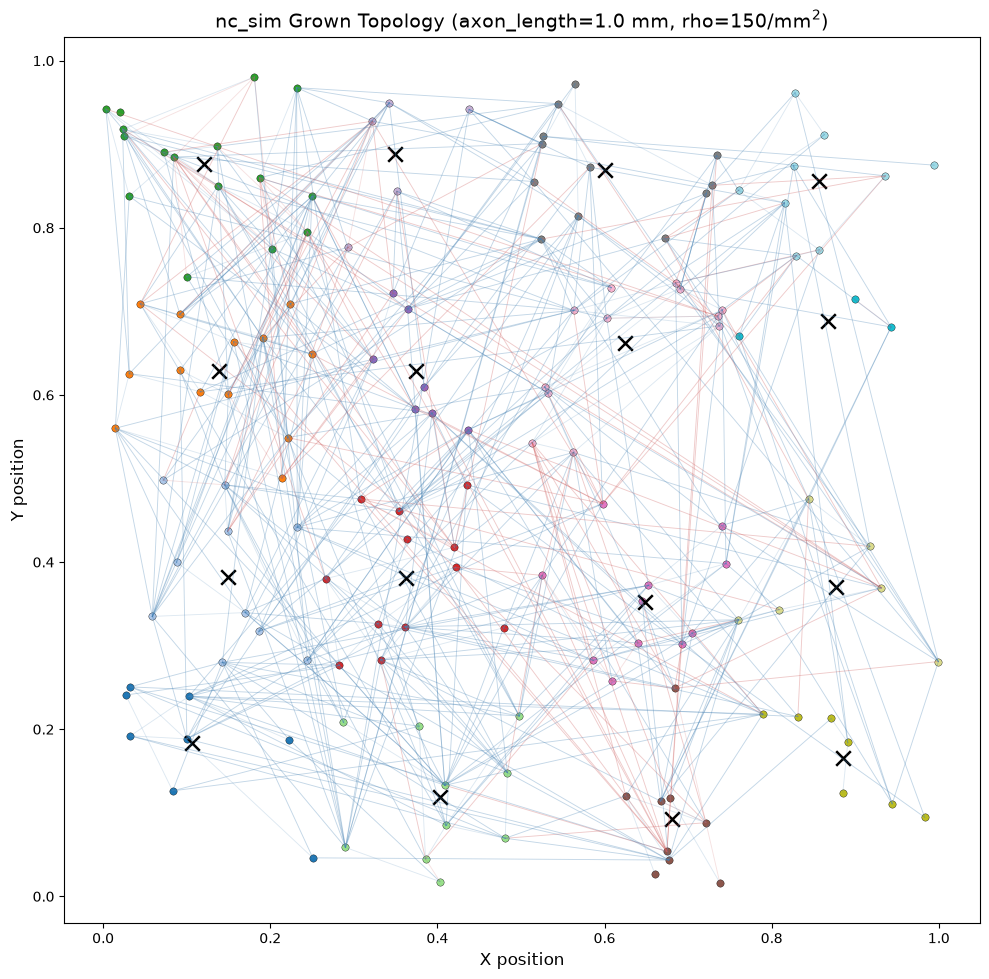

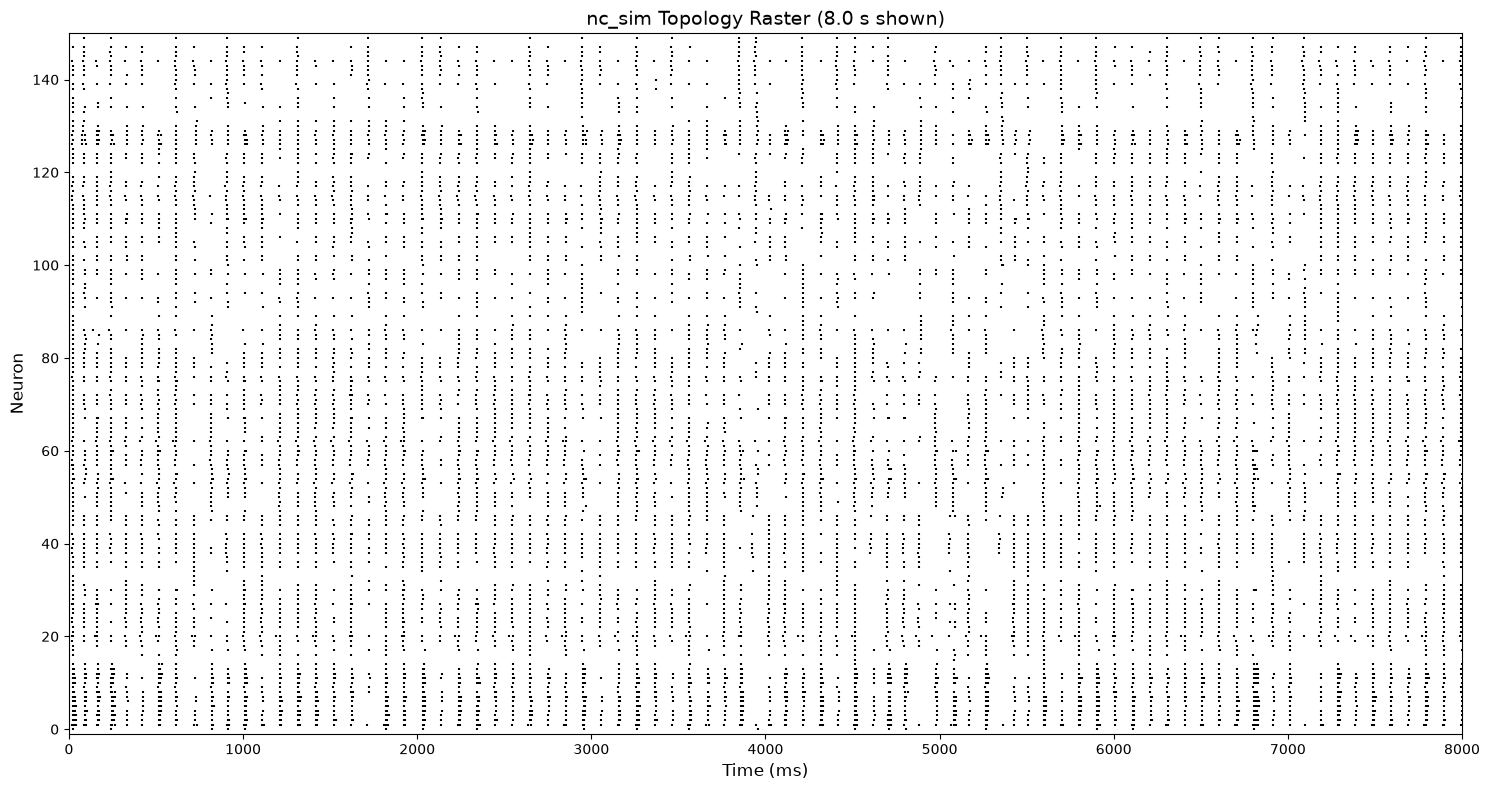

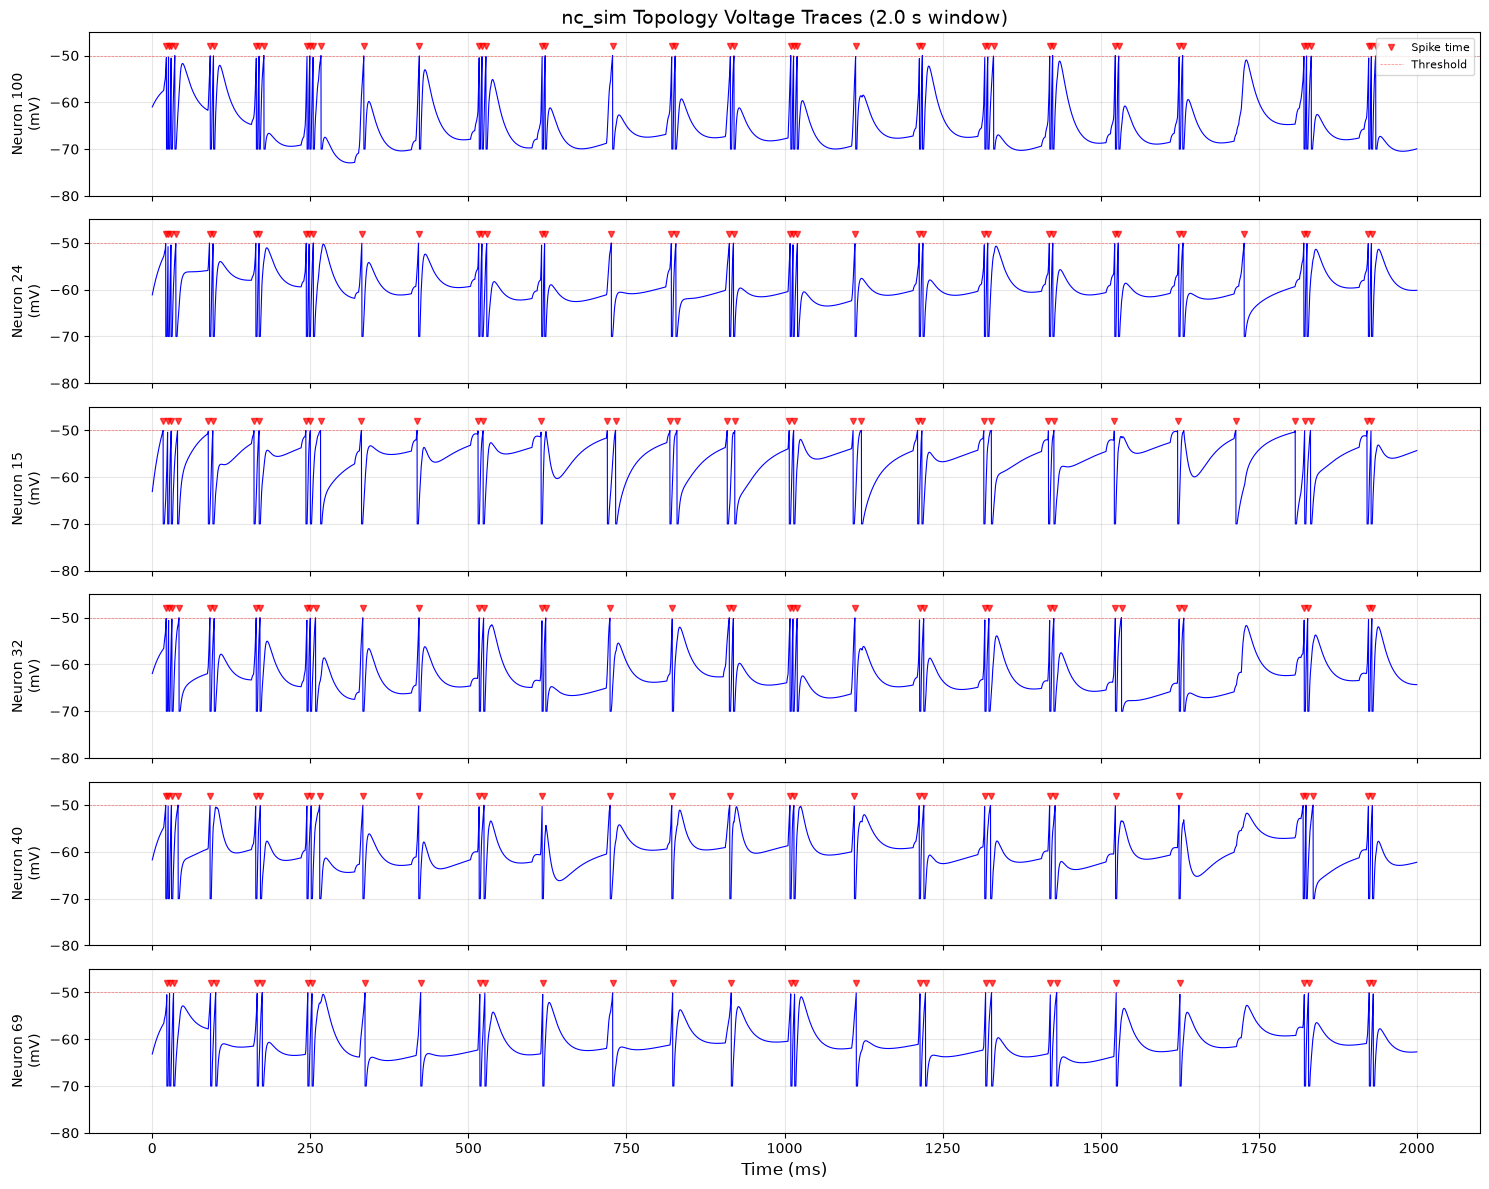

In [3]:
nc_result = run_no_stimulation_validation(**nc_sim_validation_config)
nc_metrics = nc_result['metrics']

print('NC_SIM_NO_STIM_TEST')
for key in [
    'network_source', 'nc_sim_rho', 'nc_sim_axon_length',
    'use_h_current', 'test_duration_s', 'n_neurons', 'total_spikes',
    'active_neurons', 'mean_rate_hz', 'median_rate_hz', 'max_rate_hz',
    'burst_windows', 'interburst_windows', 'max_active_fraction_100ms',
    'verdict',
]:
    print(f'{key}={nc_metrics[key]}')

nc_raster_spikes = {
    nid: [t for t in spikes if t <= nc_result['raster_window_ms']]
    for nid, spikes in nc_result['spike_data'].items()
}

fig = plot_combined_network_layout(
    nc_result['neuron_positions'],
    nc_result['cluster_info'],
    nc_result['connections'],
    cluster_assignments=nc_result['cluster_assignments'],
    max_connections=nc_result['max_connections_plot'],
    title='nc_sim Grown Topology (axon_length=1.0 mm, rho=150/mm$^2$)',
)
fig.savefig(os.path.join(DEMO_OUTPUT_DIR, 'nc_sim_network_layout.png'), dpi=110, bbox_inches='tight')
plt.show()

fig = plot_raster(
    nc_raster_spikes,
    nc_result['cluster_assignments'],
    nc_result['raster_window_ms'],
    title=f"nc_sim Topology Raster ({nc_result['raster_window_ms'] / 1000.0:.1f} s shown)",
)
fig.savefig(os.path.join(DEMO_OUTPUT_DIR, 'nc_sim_raster.png'), dpi=110, bbox_inches='tight')
plt.show()

fig = plot_voltage_traces(
    nc_result['voltage_data'],
    neuron_ids=nc_result['example_neuron_ids'],
    time_range=(0, nc_result['voltage_window_ms']),
    spike_data=nc_result['spike_data'],
    title=f"nc_sim Topology Voltage Traces ({nc_result['voltage_window_ms'] / 1000.0:.1f} s window)",
)
fig.savefig(os.path.join(DEMO_OUTPUT_DIR, 'nc_sim_voltage_traces.png'), dpi=110, bbox_inches='tight')
plt.show()

## 2. clustered vs nc_sim — same dynamics, different wiring

Runs the default `create_clustered_network` topology under the identical dynamics and prints a side-by-side metrics table, then shows the clustered layout and raster for visual comparison with section 1.

Created 291 neurons in 20 clusters


Created 1028 base synaptic connections
  Within-cluster: 951, Between-cluster: 77

Designated 20 hub neurons (6.9% of network)
Added 607 hub connections
Total connections: 1635 (base: 1028, hub: 607)

Simulating 8000 ms of network activity...
  Mode: Spontaneous activity (no external stimulation)
  External stimulation events: 0
  Built synapse lookup: 283 presynaptic neurons
  Voltage recording: raw membrane voltage at every dt step (0.1000 ms)
  Progress: 0%


  Progress: 10%


  Progress: 20%


  Progress: 30%


...

  Progress: 60%


  Progress: 70%


  Progress: 80%


  Progress: 90%


  Progress: 100%
Simulation complete!

metric                                     nc_sim               clustered
-------------------------------------------------------------------------
network_source                             nc_sim               clustered
n_neurons                                     150                     291
total_spikes                                 8563                    9961
active_neurons                                149                     243
mean_rate_hz                                7.136                   4.279
max_rate_hz                                 21.12                   22.38
burst_windows                                  83                      20
interburst_windows                             83                      21
max_active_fraction_100ms                    0.92                  0.7216
verdict                      FAIL_burst_dominated  PASS_spontaneous_baseline_bursts


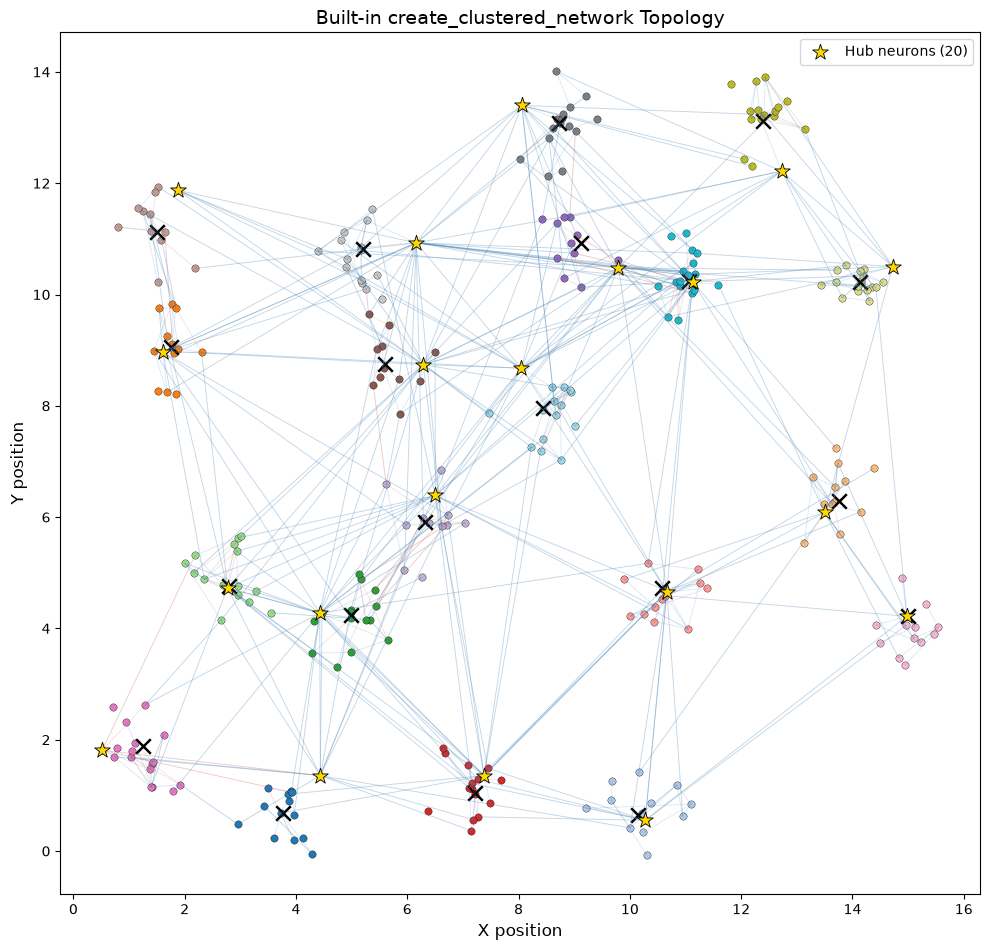

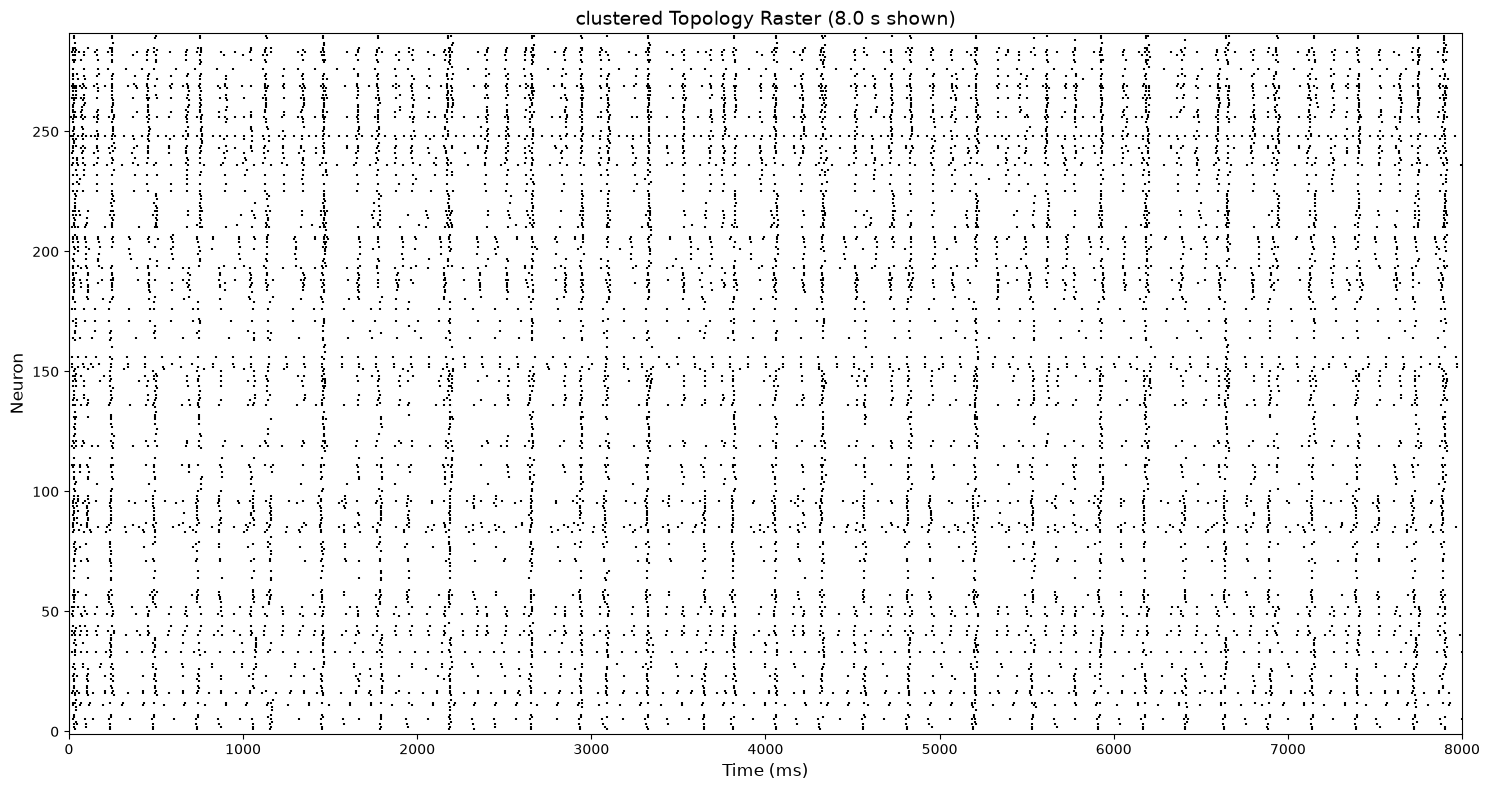

In [4]:
clustered_result = run_no_stimulation_validation(**clustered_validation_config)
cl_metrics = clustered_result['metrics']

rows = [
    'network_source', 'n_neurons', 'total_spikes', 'active_neurons',
    'mean_rate_hz', 'max_rate_hz', 'burst_windows', 'interburst_windows',
    'max_active_fraction_100ms', 'verdict',
]
width_key = max(len(r) for r in rows)
print(f"{'metric':<{width_key}}  {'nc_sim':>22}  {'clustered':>22}")
print('-' * (width_key + 48))
for r in rows:
    nv, cv = nc_metrics[r], cl_metrics[r]
    nv = f'{nv:.4g}' if isinstance(nv, float) else str(nv)
    cv = f'{cv:.4g}' if isinstance(cv, float) else str(cv)
    print(f'{r:<{width_key}}  {nv:>22}  {cv:>22}')

cl_raster_spikes = {
    nid: [t for t in spikes if t <= clustered_result['raster_window_ms']]
    for nid, spikes in clustered_result['spike_data'].items()
}

fig = plot_combined_network_layout(
    clustered_result['neuron_positions'],
    clustered_result['cluster_info'],
    clustered_result['connections'],
    cluster_assignments=clustered_result['cluster_assignments'],
    max_connections=clustered_result['max_connections_plot'],
    title='Built-in create_clustered_network Topology',
)
fig.savefig(os.path.join(DEMO_OUTPUT_DIR, 'clustered_network_layout.png'), dpi=110, bbox_inches='tight')
plt.show()

fig = plot_raster(
    cl_raster_spikes,
    clustered_result['cluster_assignments'],
    clustered_result['raster_window_ms'],
    title=f"clustered Topology Raster ({clustered_result['raster_window_ms'] / 1000.0:.1f} s shown)",
)
fig.savefig(os.path.join(DEMO_OUTPUT_DIR, 'clustered_raster.png'), dpi=110, bbox_inches='tight')
plt.show()

## 3. Axon-length sweep — the structural burst-synchrony dial

`nc_sim_axon_length` (L) is an axis *independent* of the dynamical knobs (adaptation, baseline drive, stimulus mode). Holding density, seed, and dynamics fixed, only L is varied — so the neuron positions are identical across runs and only the grown wiring changes. Short L → sparse, fragmented, weak global bursting; long L → dense, globally synchronized bursting.

The panel below shows the raster for each L (top) and two regime metrics vs L (bottom): `max_active_fraction_100ms` (peak population synchrony, rises with L) and `interburst_spike_fraction` (share of spikes outside bursts, i.e. baseline activity, falls with L).

[nc_sim_adapter] 150 neurons (120 exc / 30 inh), 2966 synapses, density 0.133, 16 spatial clusters, L=0.3 mm, rho=150.0/mm^2

Simulating 6000 ms of network activity...
  Mode: Spontaneous activity (no external stimulation)
  External stimulation events: 0
  Built synapse lookup: 150 presynaptic neurons
  Voltage recording: raw membrane voltage at every dt step (0.1000 ms)
  Progress: 0%


  Progress: 10%


  Progress: 20%


  Progress: 30%


  Progress: 40%


...

  Progress: 60%


  Progress: 70%


  Progress: 80%


  Progress: 90%


  Progress: 100%
Simulation complete!

axon_length | n_neurons | total_spikes | mean_rate_hz | burst_windows | interburst_spike_fraction | max_active_fraction_100ms | verdict
---------------------------------------------------------------------------------------------------------------------------------------
       0.30 | 150 | 5798 | 6.442 | 58 | 0.4226 | 0.8067 | FAIL_burst_dominated
       0.60 | 150 | 6110 | 6.789 | 60 | 0.2768 | 0.8933 | FAIL_burst_dominated
       1.00 | 150 | 6318 | 7.02 | 62 | 0.2373 | 0.92 | FAIL_burst_dominated


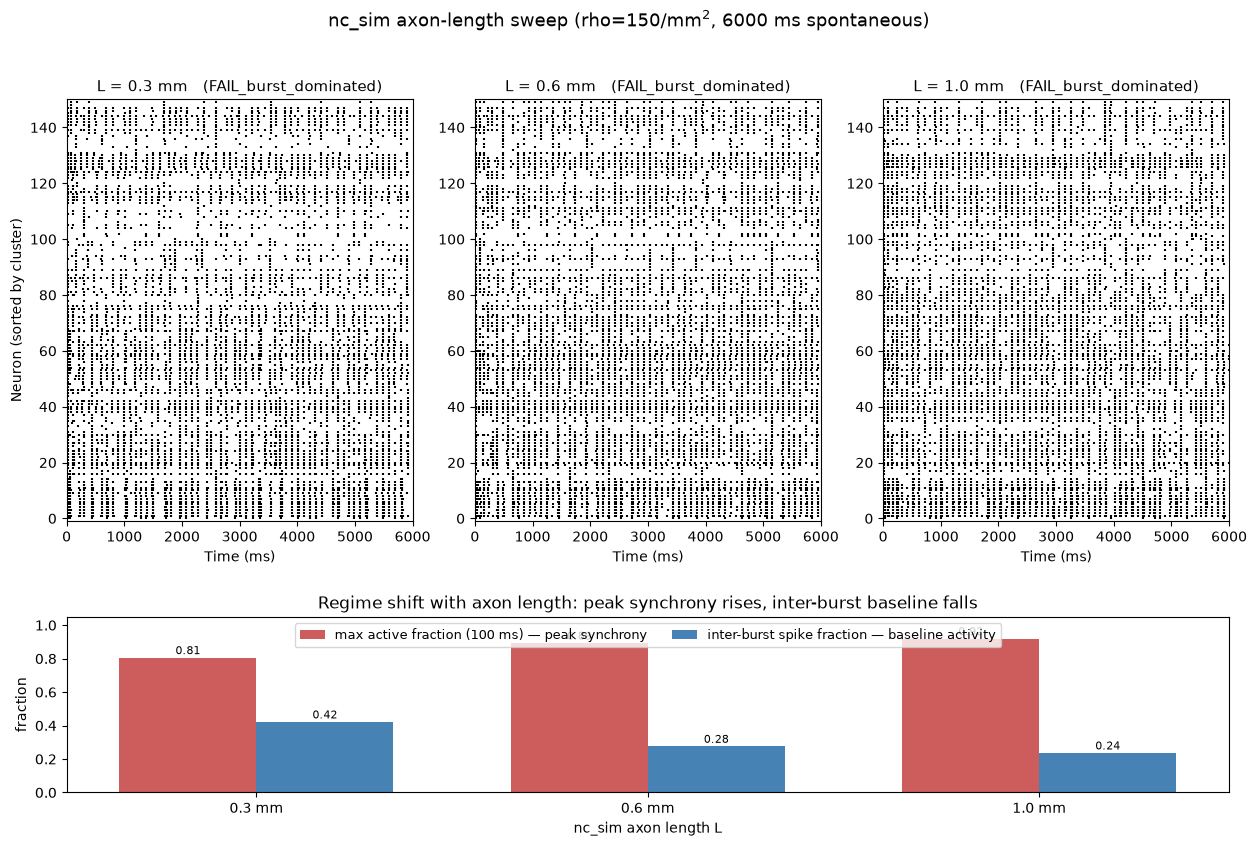

In [5]:
# L is the structural burst-synchrony dial; density/seed/dynamics held fixed.
sweep_axon_lengths = [0.3, 0.6, 1.0]
sweep_duration_ms = 6000  # a touch shorter than section 1 to keep the sweep quick

sweep_results = []
for L in sweep_axon_lengths:
    cfg = {
        **shared_validation,
        'test_duration_ms': sweep_duration_ms,
        'network_source': 'nc_sim',
        'nc_sim_width': 1.0,
        'nc_sim_height': 1.0,
        'nc_sim_rho': 150.0,
        'nc_sim_axon_length': L,
        'num_clusters': 16,
    }
    sweep_results.append((L, run_no_stimulation_validation(**cfg)))

# --- summary table ---
cols = ['n_neurons', 'total_spikes', 'mean_rate_hz', 'burst_windows',
        'interburst_spike_fraction', 'max_active_fraction_100ms', 'verdict']
header = f"{'axon_length':>11} | " + ' | '.join(cols)
print(header)
print('-' * len(header))
for L, res in sweep_results:
    m = res['metrics']
    vals = [f'{m[c]:.4g}' if isinstance(m[c], float) else str(m[c]) for c in cols]
    print(f'{L:>11.2f} | ' + ' | '.join(vals))

# --- panel: rasters (top row) + regime metrics vs L (bottom) ---
n_panels = len(sweep_results)
fig = plt.figure(figsize=(5 * n_panels, 9))
gs = fig.add_gridspec(2, n_panels, height_ratios=[2.4, 1.0], hspace=0.32, wspace=0.18)

for col, (L, res) in enumerate(sweep_results):
    ax = fig.add_subplot(gs[0, col])
    spike_data = res['spike_data']
    ca = res['cluster_assignments']
    order = sorted(spike_data.keys(), key=lambda idx: ca[idx])
    for row_idx, nid in enumerate(order):
        spikes = spike_data[nid]
        if len(spikes) > 0:
            ax.scatter(spikes, [row_idx] * len(spikes), s=1, c='k', marker='|')
    ax.set_xlim(0, sweep_duration_ms)
    ax.set_ylim(-1, len(order))
    ax.set_title(f"L = {L} mm   ({res['metrics']['verdict']})", fontsize=11)
    ax.set_xlabel('Time (ms)')
    if col == 0:
        ax.set_ylabel('Neuron (sorted by cluster)')

axm = fig.add_subplot(gs[1, :])
Ls = [L for L, _ in sweep_results]
max_active = [res['metrics']['max_active_fraction_100ms'] for _, res in sweep_results]
interburst = [res['metrics']['interburst_spike_fraction'] for _, res in sweep_results]
x = np.arange(len(Ls))
bw = 0.35
axm.bar(x - bw / 2, max_active, bw, label='max active fraction (100 ms) — peak synchrony', color='indianred')
axm.bar(x + bw / 2, interburst, bw, label='inter-burst spike fraction — baseline activity', color='steelblue')
axm.set_xticks(x)
axm.set_xticklabels([f'{L} mm' for L in Ls])
axm.set_ylim(0, 1.05)
axm.set_ylabel('fraction')
axm.set_xlabel('nc_sim axon length L')
axm.set_title('Regime shift with axon length: peak synchrony rises, inter-burst baseline falls')
axm.legend(loc='upper center', ncol=2, fontsize=9)
for i, (ma, ib) in enumerate(zip(max_active, interburst)):
    axm.text(i - bw / 2, ma + 0.02, f'{ma:.2f}', ha='center', fontsize=8)
    axm.text(i + bw / 2, ib + 0.02, f'{ib:.2f}', ha='center', fontsize=8)

fig.suptitle(f'nc_sim axon-length sweep (rho=150/mm$^2$, {sweep_duration_ms} ms spontaneous)', fontsize=13)
fig.savefig(os.path.join(DEMO_OUTPUT_DIR, 'nc_sim_axon_length_sweep.png'), dpi=110, bbox_inches='tight')
plt.show()

## 4. (Optional) full saved nc_sim session

Set `execute_main_simulation = True` in the configuration cell to grow + simulate + save a full session using the nc_sim topology, then load it back and confirm that `network_source` and the nc_sim parameters are recorded in `session_metadata.json`.

In [6]:
if execute_main_simulation:
    np.random.seed(seed)
    random.seed(seed)
    session_metadata = sequential_simulation_individual_saves(**nc_sim_simulation_params)
    print('Saved nc_sim session to:', session_metadata['session_dir'])
    print('network_source:', session_metadata['network_source'])
    print('nc_sim_params:', session_metadata['nc_sim_params'])

    bundle = load_session_bundle(session_source='latest', recording_index=0)
    activity = 'stimulus-driven' if bundle['stimulation_enabled'] else 'spontaneous firing'
    fig = plot_raster(
        bundle['spike_data_dict'],
        bundle['cluster_assignments'],
        bundle['recording_duration'],
        title=f"Saved nc_sim Recording Raster ({bundle['recording_duration'] / 1000:.0f}s, {activity})",
    )
    plt.show()
    plot_firing_rates(bundle['spike_data_dict'], bundle['cluster_assignments'], bundle['recording_duration'])
    plt.show()
else:
    print('Saved nc_sim session skipped. Set execute_main_simulation = True to run it.')

Saved nc_sim session skipped. Set execute_main_simulation = True to run it.
